## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Claire Curzan

**Date:** 9/30/2026

338
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64
height
0.181818    30
0.545455    30
0.636364    30
0.454545    29
0.727273    29
0.818182    29
0.363636    

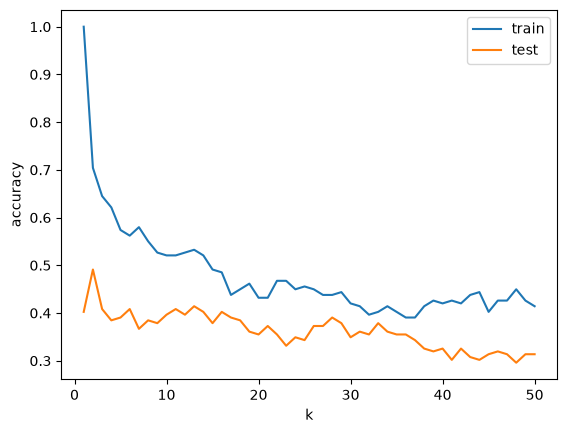

col_0       1   2   3  4  5
mine_type                  
1          28   0   9  1  0
2           0  29   3  1  2
3           8   0  15  5  5
4          13   2  11  9  0
5          10   0  12  4  2
accuracy: 0.4911242603550296


In [9]:
# Your Phase 1 solution to the problem goes here.

### Q1 ###

# 1) The difference between regression and classification is the kind of target being predicted. Regression predicts a numeric outcome, 
# like baseline sales, and classification predicts a category, like class. In kNN specifically, the only difference is in the last step:
# for regression you average the outcomes of the k nearest neighbors, and for classification you predict the most common class among them.

# 2) A confusion table is a table that counts predictions by actual class and predicted class, with rows as the actual classes and columns as
# the predictions. The diagonal cells are the correct predictions and the off-diagonal cells are the misclassifications. It helps us understand
# which classes the model gets wrong and what it confuses them with (false positives vs false negatives).

# 3) The SSE quantifies the total size of a model's prediction errors. The residual for an observation is the actual value minus the predicted
# value, and the SSE squares all the residuals and adds them up. A lower SSE on the validation set means the model makes smaller errors on that
# set.

# 4) Overfitting is when the model fits the noise in the training data, so it does well on the training data but badly on new data. Overfitting
# happens when k is very small. Underfitting is when the model is too simple to pick up real differences between observations. Underfitting 
# happens when k is very large, because averaging that many neighbors gives nearly the same prediction for everything.

# 5) Splitting the data into training and testing sets and choosing k on the test set improves model performance because what we care about is
# generalization (how well the model predicts data that was not used to fit it). If you choose k by training error alone, you would pick a
# very small k, since the predictions follow the training data closely, and that overfits. Evaluating on the test set estimates how the model
# will do on future data. Picking the k with the lowest SSE (or highest accuracy) there avoids both a k that is too small, which overfits,
# and a k that is too large, which underfits. The best k depends on which observations randomly end up in the training and test sets, so a
# different split could give a different best k.

# 6) With classification, kNN can report a class label by predicting the most common class among the neighbors, or a probability distribution 
# by dividing each class's neighbor count by k.
#         Class Label: The strength of reporting a class label is that it is simple and gives one clear answer to act on, and it is easy to
#           evaluate with accuracy and a confusion table. The weakness is that it hides how sure the model is. With k = 5, a 3 to 2 vote and a 
#           5 to 0 vote give the same label.
#
#         Probability Distribution: The strength of reporting a probability distribution is that it shows how confident the model is and what
#           the second most likely class is. That matters when false positives and false negatives have different costs, because the user can
#           choose their own cutoff. The weaknesses are that it is harder to read and evaluate, and someone still has to turn it into a decision.
#           With a small k the proportions are also very rough (with k = 3 they can only be 0, 1/3, 2/3 or 1).

### Q2 ###

# 1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

mine_df = pd.read_csv("./data/land_mines.csv")
print(len(mine_df))
print(mine_df.head())
print(mine_df.describe())

# target label
print(mine_df["mine_type"].value_counts())

# features
print(mine_df["soil"].value_counts())
print(mine_df["height"].value_counts())

# average of each feature by mine type
print(mine_df.groupby("mine_type")[["voltage", "height", "soil"]].mean())

# Summary of the EDA for 2.1:
# There are 338 rows and no missing values. The target (mine_type) takes values 1 to 5 and the classes are balanced (65 to 71 each).
# The three features all range from about 0 to 1. voltage is skewed right (mean 0.43, median 0.36), height takes 12 different values, and
# soil takes 6 values that each show up about equally.
# Type 2 has a much higher average voltage (0.72) than the others, and type 1 has the lowest (0.30). Types 3, 4 and 5 are close together
# (0.35 to 0.40), and height and soil averages are about the same for every type, so I expect types 3, 4 and 5 to be hard to tell apart.

# 2) Split 50/50 so 169 training and 169 test set
X = mine_df[["voltage", "height", "soil"]]
y = mine_df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3)
ks = np.arange(1, 51)
test_acc = []
train_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    test_hat = model.predict(X_test_scaled)
    train_hat = model.predict(X_train_scaled)
    test_acc.append(np.sum(test_hat == y_test) / len(y_test))
    train_acc.append(np.sum(train_hat == y_train) / len(y_train))

k_star = int(ks[np.argmax(test_acc)])
print("best k:", k_star)
print("test accuracy at best k:", max(test_acc))

plt.plot(ks, train_acc, label="train")
plt.plot(ks, test_acc, label="test")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.show()

# How I select k: 
# I tried every k from 1 to 50. For each one, I fit the model on the training set and checked how accurate it was on the
# test set. Then I picked the k with the highest test accuracy, which was k = 2 (about 0.49). I used the test accuracy and not the training
# accuracy because the training accuracy is always best when k is tiny. At k = 1 the training accuracy is 1.0 but the test accuracy is only 
# about 0.40, so the model is overfitting. When k gets big the test accuracy drops to around 0.30, so the model is underfitting.

# 4)
best_model = KNeighborsClassifier(n_neighbors=k_star)
best_model.fit(X_train_scaled, y_train)
y_hat = best_model.predict(X_test_scaled)

print(pd.crosstab(y_test, y_hat))

accuracy = np.sum(y_hat == y_test) / len(y_test)
print("accuracy:", accuracy)

# Answers to questions in 4:
# How accurate is it? The diagonal cells are the correct predictions, and they add up to 28 + 29 + 15 + 9 + 2 = 83 out of 169 test
# observations, so the accuracy is 83/169 = 0.49. That is better than random guessing, which would be about 0.20 with 5 balanced classes, 
# but my model is still wrong about half the time.

# Where is performance more accurate? Performance is most accurate for type 2, where 29 of the 35 actual type 2 mines are predicted correctly
# (83%). This makes sense because type 2 has a much higher average voltage than the other types, so its neighbors are mostly other type 2 mines.
# Type 1 is next, with 28 of 38 correct (74%).

# Where is performance less accurate? Performance is less accurate for types 3, 4 and 5. Type 3 is 15 of 33 correct (45%), type 4 is 9 of 35 
# (26%), and type 5 is the worst at 2 of 28 (7%). My model only predicts type 5 nine times in total. Most of the actual type 4 and type 5 mines
# get predicted as type 1 or type 3. This matches the EDA, where types 3, 4 and 5 had almost the same average voltage, height and soil, so their
# nearest neighbors are a mix of classes.

# 5)
# I'd advise someone to use this predictive model as a first guess, not a final answer, because of the errors it tends to make. The model catches
# 28 of the 38 actual type 1 mines, which looks accurate, but it predicted type 1 a total of 59 times and was only right on 28 of those (47%).
# So, it gets a lot of type 1 mines correct mostly because it predicts that label so often, and the same thing happens with type 3 (15 right out
# of 50 predictions).

# Given that, I'd advise them to mostly trust a prediction of type 2, since 29 of the 31 type 2 predictions were correct (94%). A prediction of
# type 1 or type 3 should not be treated as confirmed, because a lot of type 4 and type 5 mines get mislabeled as those. My model misses almost
# all of the type 5 mines, so the crew should still handle every mine carefully and plan for the most dangerous type it could be, since a wrong
# call could get someone hurt.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** db90bed9e531b342596c07f2bf03646d30e94a91
- **AI tool and model used:** Claude Opus 5.5

### *Prompts used

1. Can you review my answers and code for the following questions and suggest improvements?
2. Do these changes affect correctness/are cleaner code/or more efficient way of getting the right answer?f

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Your k = 2 result is partly a tie-breaking artifact. With two neighbors, any disagreement is a 1–1 tie, and sklearn breaks ties by picking the lower class label. That is likely a big reason type 1 is predicted 59 times and type 5 only 9 times, which Q4 currently attributes entirely to overlapping features. The check below shows how many predictions were ties. To fix it, search odd k only or use weights="distance", then update the numbers in your written answers for parts 3 to 5.

2. Add stratify=y to train_test_split. Your test set has only 28 type 5 mines against 38 type 1, which is the imbalance the assignment warns about. Stratifying keeps each class split evenly. It will also change your numbers.

3. soil may be a category rather than a quantity. In the UCI version, the six soil values are codes for soil types (dry sandy, wet humus and so on), so treating 0.0 and 0.2 as "close" is arbitrary. If your documentation agrees, try one-hot encoding it with pd.get_dummies and see if test accuracy improves.

4. Add a boxplot of voltage by mine type to the EDA to support claim you make from the averages.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Modify | The AI first suggested switching to odd k or distance weights. Testing showed both lower accuracy on my split (0.414 at k = 13 and 0.402 at k = 1, vs 0.491), so I kept k = 2. The tie check confirmed 119 of 169 test predictions were 1–1 ties, all resolved to the lower label, and type 5 never won a tie. Over 40 random splits k = 2 averaged 0.44, so 0.49 is optimistic. |
| 2 | Reject | Tested: gives k = 3 at 0.467 with a similar confusion table, so conclusions do not change, but every number in my write-up would. |
| 3 | Reject | Tested: accuracy falls from 0.491 to 0.462 on my split, with k = 2 still best. One-hot encoding would be the better representation if soil is a category code, but it did not improve predictions here, so I kept the original features. |
| 4 | Accept | Shows the overlap between types 3, 4 and 5 directly, and more proof for my claims is always better. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

338
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
soil
0.0    59
0.8    58
0.6    57
1.0    57
0.4    56
0.2    51
Name: count, dtype: int64
height
0.181818    30
0.545455    30
0.636364    30
0.454545    29
0.727273    29
0.818182    29
0.363636    

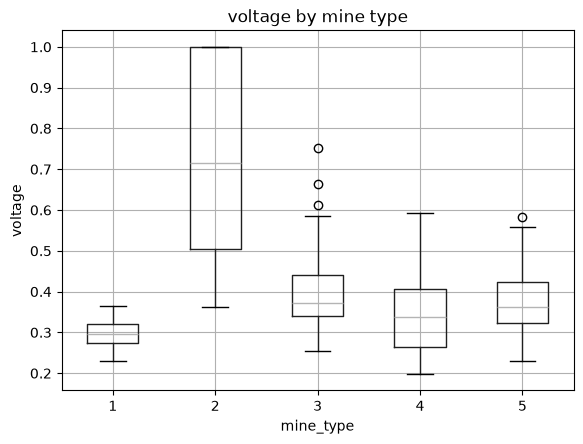

best k: 2
test accuracy at best k: 0.4911242603550296


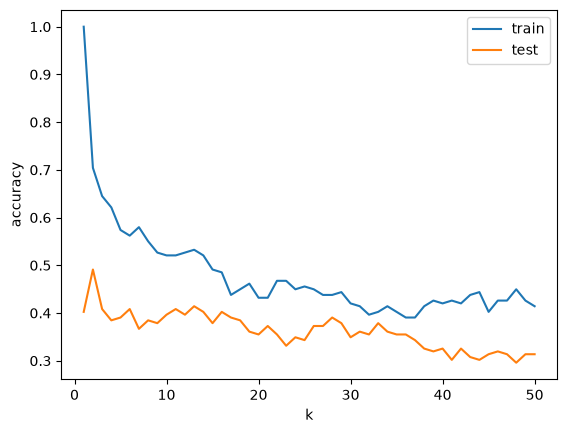

col_0       1   2   3  4  5
mine_type                  
1          28   0   9  1  0
2           0  29   3  1  2
3           8   0  15  5  5
4          13   2  11  9  0
5          10   0  12  4  2
accuracy: 0.4911242603550296
119 of 169 test predictions were 1-1 ties
predicted labels on ties:
1    50
2    13
3    41
4    15
Name: count, dtype: int64
accuracy on ties: 0.46218487394957986
accuracy on non-ties: 0.56
k = 2 accuracy over 40 splits: mean 0.43535502958579875 min 0.3727810650887574 max 0.4911242603550296


In [11]:
# Your Phase 2 solution to the problem goes here.

### Q1 ###

# 1) The difference between regression and classification is the kind of target being predicted. Regression predicts a numeric outcome, 
# like baseline sales, and classification predicts a category, like class. In kNN specifically, the only difference is in the last step:
# for regression you average the outcomes of the k nearest neighbors, and for classification you predict the most common class among them.

# 2) A confusion table is a table that counts predictions by actual class and predicted class, with rows as the actual classes and columns as
# the predictions. The diagonal cells are the correct predictions and the off-diagonal cells are the misclassifications. It helps us understand
# which classes the model gets wrong and what it confuses them with (false positives vs false negatives).

# 3) The SSE quantifies the total size of a model's prediction errors. The residual for an observation is the actual value minus the predicted
# value, and the SSE squares all the residuals and adds them up. A lower SSE on the validation set means the model makes smaller errors on that
# set.

# 4) Overfitting is when the model fits the noise in the training data, so it does well on the training data but badly on new data. Overfitting
# happens when k is very small. Underfitting is when the model is too simple to pick up real differences between observations. Underfitting 
# happens when k is very large, because averaging that many neighbors gives nearly the same prediction for everything.

# 5) Splitting the data into training and testing sets and choosing k on the test set improves model performance because what we care about is
# generalization (how well the model predicts data that was not used to fit it). If you choose k by training error alone, you would pick a
# very small k, since the predictions follow the training data closely, and that overfits. Evaluating on the test set estimates how the model
# will do on future data. Picking the k with the lowest SSE (or highest accuracy) there avoids both a k that is too small, which overfits,
# and a k that is too large, which underfits. The best k depends on which observations randomly end up in the training and test sets, so a
# different split could give a different best k.

# 6) With classification, kNN can report a class label by predicting the most common class among the neighbors, or a probability distribution 
# by dividing each class's neighbor count by k.
#         Class Label: The strength of reporting a class label is that it is simple and gives one clear answer to act on, and it is easy to
#           evaluate with accuracy and a confusion table. The weakness is that it hides how sure the model is. With k = 5, a 3 to 2 vote and a 
#           5 to 0 vote give the same label.
#
#         Probability Distribution: The strength of reporting a probability distribution is that it shows how confident the model is and what
#           the second most likely class is. That matters when false positives and false negatives have different costs, because the user can
#           choose their own cutoff. The weaknesses are that it is harder to read and evaluate, and someone still has to turn it into a decision.
#           With a small k the proportions are also very rough (with k = 3 they can only be 0, 1/3, 2/3 or 1).

### Q2 ###

# 1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

mine_df = pd.read_csv("./data/land_mines.csv")
print(len(mine_df))
print(mine_df.head())
print(mine_df.describe())

# target label
print(mine_df["mine_type"].value_counts())

# features
print(mine_df["soil"].value_counts())
print(mine_df["height"].value_counts())

# average of each feature by mine type
print(mine_df.groupby("mine_type")[["voltage", "height", "soil"]].mean())

# Phase 2 change (accepted change 4): boxplot of voltage by mine type
mine_df.boxplot(column="voltage", by="mine_type")
plt.suptitle("")
plt.title("voltage by mine type")
plt.xlabel("mine_type")
plt.ylabel("voltage")
plt.show()

# Summary of the EDA for 2.1:
# There are 338 rows and no missing values. The target (mine_type) takes values 1 to 5 and the classes are balanced (65 to 71 each).
# The three features all range from about 0 to 1. voltage is skewed right (mean 0.43, median 0.36), height takes 12 different values, and
# soil takes 6 values that each show up about equally.
# Type 2 has a much higher average voltage (0.72) than the others, and type 1 has the lowest (0.30). Types 3, 4 and 5 are close together
# (0.35 to 0.40), and height and soil averages are about the same for every type, so I expect types 3, 4 and 5 to be hard to tell apart.

# Phase 2 addition: The boxplot shows this overlap directly. The boxes for types 3, 4 and 5 sit almost on top of each other (medians of
# 0.37, 0.34 and 0.36), and the type 1 box (0.27 to 0.32) falls inside the range of all three. Type 1 is tightly bunched, with every value
# between 0.23 and 0.37. Type 2 is the only one that stands apart, with a median of 0.72, but its lowest values (down to 0.36) still reach
# into the range of the other types.

# 2) Split 50/50 so 169 training and 169 test set
X = mine_df[["voltage", "height", "soil"]]
y = mine_df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3)
ks = np.arange(1, 51)
test_acc = []
train_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    test_hat = model.predict(X_test_scaled)
    train_hat = model.predict(X_train_scaled)
    test_acc.append(np.sum(test_hat == y_test) / len(y_test))
    train_acc.append(np.sum(train_hat == y_train) / len(y_train))

k_star = int(ks[np.argmax(test_acc)])
print("best k:", k_star)
print("test accuracy at best k:", max(test_acc))

plt.plot(ks, train_acc, label="train")
plt.plot(ks, test_acc, label="test")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.show()

# How I select k: 
# I tried every k from 1 to 50. For each one, I fit the model on the training set and checked how accurate it was on the
# test set. Then I picked the k with the highest test accuracy, which was k = 2 (about 0.49). I used the test accuracy and not the training
# accuracy because the training accuracy is always best when k is tiny. At k = 1 the training accuracy is 1.0 but the test accuracy is only 
# about 0.40, so the model is overfitting. When k gets big the test accuracy drops to around 0.30, so the model is underfitting.

# Phase 2 addition (change 1, modified): k = 2 is a special case. With two neighbors, any time they disagree the vote is a 1 to 1 tie, and
# sklearn breaks the tie by predicting the lower class label. The tie check in part 4 shows this happens for 119 of the 169 test
# observations, so part of the reason k = 2 beats k = 1 (0.40) and k = 3 (0.41) is this tie rule and not only the extra neighbor. I tested
# two ways of avoiding ties, searching odd k only (best was k = 13 at 0.414) and using weights="distance" (best was k = 1 at 0.402). Both
# were less accurate on my test set, so I kept k = 2, since it is still the k with the highest test accuracy.

# 4)
best_model = KNeighborsClassifier(n_neighbors=k_star)
best_model.fit(X_train_scaled, y_train)
y_hat = best_model.predict(X_test_scaled)

print(pd.crosstab(y_test, y_hat))

accuracy = np.sum(y_hat == y_test) / len(y_test)
print("accuracy:", accuracy)

# Phase 2 change (change 1, modified): tie check. With k = 2, a top probability of 0.5 means the two neighbors disagreed
proba = best_model.predict_proba(X_test_scaled)
tied = proba.max(axis=1) == 0.5
print(tied.sum(), "of", len(tied), "test predictions were 1-1 ties")
print("predicted labels on ties:")
print(pd.Series(y_hat[tied]).value_counts().sort_index())
print("accuracy on ties:", np.sum(y_hat[tied] == y_test[tied]) / tied.sum())
print("accuracy on non-ties:", np.sum(y_hat[~tied] == y_test[~tied]) / (~tied).sum())

# Phase 2 change (change 1, modified): how accurate is k = 2 on other random splits
split_acc = []
for seed in range(40):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.50, random_state=seed)
    sc = MinMaxScaler()
    Xa = sc.fit_transform(Xa)
    Xb = sc.transform(Xb)
    m = KNeighborsClassifier(n_neighbors=k_star)
    m.fit(Xa, ya)
    split_acc.append(np.sum(m.predict(Xb) == yb) / len(yb))
print("k = 2 accuracy over 40 splits: mean", np.mean(split_acc), "min", np.min(split_acc), "max", np.max(split_acc))

# Answers to questions in 4:
# How accurate is it? The diagonal cells are the correct predictions, and they add up to 28 + 29 + 15 + 9 + 2 = 83 out of 169 test
# observations, so the accuracy is 83/169 = 0.49. That is better than random guessing, which would be about 0.20 with 5 balanced classes, 
# but my model is still wrong about half the time.

# Phase 2 addition: 0.49 is optimistic. I chose k using this same test set, and when I reran k = 2 on 40 other random splits the accuracy
# averaged 0.44 and ranged from 0.37 to 0.49, so my split is at the top of that range. A fairer estimate of the accuracy is about 0.44.

# Where is performance more accurate? Performance is most accurate for type 2, where 29 of the 35 actual type 2 mines are predicted correctly
# (83%). This makes sense because type 2 has a much higher average voltage than the other types, so its neighbors are mostly other type 2 mines.
# Type 1 is next, with 28 of 38 correct (74%).

# Where is performance less accurate? Performance is less accurate for types 3, 4 and 5. Type 3 is 15 of 33 correct (45%), type 4 is 9 of 35 
# (26%), and type 5 is the worst at 2 of 28 (7%). My model only predicts type 5 nine times in total. Most of the actual type 4 and type 5 mines
# get predicted as type 1 or type 3. This matches the EDA, where types 3, 4 and 5 had almost the same average voltage, height and soil, so their
# nearest neighbors are a mix of classes.

# Phase 2 addition: The overlap is not the only reason. The tie check shows 119 of the 169 test predictions were 1 to 1 ties, and on a tie
# sklearn predicts the lower label. The tied predictions were type 1 fifty times, type 3 forty-one times, type 4 fifteen times, type 2
# thirteen times, and type 5 zero times. Type 5 is the highest label, so it can never win a tie, and all 9 of the type 5 predictions came
# from the 50 cases where both neighbors agreed. So the pattern of over-predicting types 1 and 3 and almost never predicting type 5 comes
# partly from how the classes are numbered, not just from the features.

# 5)
# I'd advise someone to use this predictive model as a first guess, not a final answer, because of the errors it tends to make. The model catches
# 28 of the 38 actual type 1 mines, which looks accurate, but it predicted type 1 a total of 59 times and was only right on 28 of those (47%).
# So, it gets a lot of type 1 mines correct mostly because it predicts that label so often, and the same thing happens with type 3 (15 right out
# of 50 predictions).

# Given that, I'd advise them to mostly trust a prediction of type 2, since 29 of the 31 type 2 predictions were correct (94%). A prediction of
# type 1 or type 3 should not be treated as confirmed, because a lot of type 4 and type 5 mines get mislabeled as those. My model misses almost
# all of the type 5 mines, so the crew should still handle every mine carefully and plan for the most dangerous type it could be, since a wrong
# call could get someone hurt.

# Phase 2 addition: I'd also advise them to look at the predicted probabilities and not just the label. With k = 2, a top probability of 0.5
# means the two neighbors disagreed and the label was decided by the tie rule, which always picks the lower-numbered type. That was the case for
# 70% of the test predictions (119 of 169), including 50 of the 59 type 1 predictions and 41 of the 50 type 3 predictions. A tied prediction
# should be reported as "one of these two types" and not as a single answer.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements were to how I checked and explained my k-NN model, not really editing the model itself. I kept k = 2 but added a tie check, a test of k = 2 on 40 other random splits, and a boxplot of voltage by mine type, which shows directly that types 3, 4 and 5 overlap and that only type 2 stands apart. The AI's suggestions were mostly standard advice that did not hold up on my data. It suggested odd k or distance weights to avoid ties, but both were less accurate on my split (0.414 at k = 13 and 0.402 at k = 1, against 0.491). One-hot encoding soil also lowered accuracy to 0.462. Change 2 gave k = 3 at 0.467 with a similar confusion table, so it would have changed every number in my write-up without changing my conclusions. I verified the final solution by running every change on my own split and comparing the accuracy and confusion tables. The tie check showed that 119 of 169 test predictions were 1 to 1 ties, all resolved to the lower label, so type 5 never won a tie. I still have two concerns. My 0.49 accuracy is probably too high, because k = 2 was just the luckiest k on my one split. On 40 other random splits it averaged 0.44, which is a fairer number. Also, about 70% of my predictions were ties, so they came from how the mine types are numbered, not from the voltage, height or soil.